# Ejemplo aplicado: clasificación binaria — Breast Cancer

Misma plantilla que [02-clasificacion-binaria.ipynb](../02-clasificacion-binaria.ipynb), configurada para `breast_cancer.csv` (target `target`, 0/1).

> Para un CSV nuevo, parte de la **plantilla genérica** correspondiente, no de este archivo.


In [1]:
# --- Imports ---
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


def infer_feature_columns(df, target_col, drop_cols, feature_cols):
    """Columnas que entran como X. Si FEATURE_COLS es None, todas salvo target y DROP_COLS."""
    if feature_cols is not None:
        return list(feature_cols)
    exclude = {target_col, *drop_cols}
    return [c for c in df.columns if c not in exclude]


def infer_column_types(X, numeric_cols=None, categorical_cols=None):
    """Separa numéricas y categóricas para ColumnTransformer."""
    if numeric_cols is None:
        numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if categorical_cols is None:
        categorical_cols = X.select_dtypes(
            include=["object", "category", "bool", "string"]
        ).columns.tolist()
    return list(numeric_cols), list(categorical_cols)


def build_preprocess(numeric_cols, categorical_cols):
    """Preprocesador compartido: imputar → escalar / one-hot. Fit solo en train (Pipeline)."""
    transformers = []
    if numeric_cols:
        transformers.append(
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_cols,
            )
        )
    if categorical_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "encoder",
                            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                        ),
                    ]
                ),
                categorical_cols,
            )
        )
    if not transformers:
        raise ValueError("No hay columnas numéricas ni categóricas para preprocesar.")
    return ColumnTransformer(transformers, remainder="drop")


def read_csv_checked(path, sep, required_cols=None):
    """Lee CSV y comprueba separador y columnas (evita KeyError si CSV_SEP ≠ PREVIEW_SEP)."""
    df = pd.read_csv(path, sep=sep)
    if df.shape[1] == 1:
        raise ValueError(
            f"Solo 1 columna con sep={sep!r}. CSV_SEP debe coincidir con PREVIEW_SEP del paso 1."
        )
    if required_cols:
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(
                f"Faltan columnas {missing}. Revisa CSV_SEP (actual {sep!r}). "
                f"Columnas leídas: {list(df.columns)}"
            )
    return df


def split_train_val_test(X, y, test_size, val_size, random_state, stratify=False):
    """Divide en train, validación y test (dos llamadas a train_test_split).

    - test_size: fracción del total para test (hold-out final, paso 9).
    - val_size: fracción de train+val; el benchmark (paso 8) usa solo val.
    Con test_size=0.2 y val_size=0.25 → ~60 % train, ~20 % val, ~20 % test.
    """
    kw = dict(test_size=test_size, random_state=random_state)
    if stratify:
        kw["stratify"] = y
    X_tv, X_test, y_tv, y_test = train_test_split(X, y, **kw)
    kw2 = dict(test_size=val_size, random_state=random_state)
    if stratify:
        kw2["stratify"] = y_tv
    X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, **kw2)
    return X_train, X_val, X_test, y_train, y_val, y_test


def discretize_series(series, n_bins=5, max_classes=25):
    """Discretiza una serie para tablas target×feature (redondeo o bins por cuantiles)."""
    s = pd.Series(series)
    if s.nunique() <= max_classes:
        return np.round(s).astype(int).to_numpy(), "valores redondeados"
    edges = np.unique(np.quantile(s.dropna(), np.linspace(0, 1, n_bins + 1)))
    if len(edges) < 2:
        edges = np.linspace(float(s.min()), float(s.max()), n_bins + 1)
    binned = np.digitize(s, edges[1:-1])
    return binned, f"{len(edges) - 1} intervalos (cuantiles)"




## 1. Explorar el CSV (antes de CONFIG)

Mismos parámetros que usarás en CONFIG.


In [2]:
# --- Ajusta solo estas dos líneas para TU csv ---
PREVIEW_PATH = "../data/breast_cancer.csv"
PREVIEW_SEP = ','

df_preview = pd.read_csv(PREVIEW_PATH, sep=PREVIEW_SEP)

print(f"Filas: {len(df_preview):,}  |  Columnas: {len(df_preview.columns)}")
print("\n--- Nombres de columnas ---")
for i, col in enumerate(df_preview.columns):
    print(f"  {i:2d}: {col!r}")

print("\n--- Tipos (dtypes) ---")
print(df_preview.dtypes)

print("\n--- Primeras filas ---")
display(df_preview.head())

print("\n--- Valores faltantes ---")
missing = df_preview.isna().sum()
if missing.any():
    display(missing[missing > 0].to_frame("nulos"))
else:
    print("No hay valores faltantes.")

_num = df_preview.select_dtypes(include=[np.number]).columns.tolist()
_cat = df_preview.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()
print("\n--- Sugerencia de tipos ---")
print("Numéricas:", _num)
print("Categóricas:", _cat)

if "target" in df_preview.columns:
    print("\n--- Distribución del posible target ---")
    print(df_preview["target"].value_counts())

print(
    "\n>>> Siguiente: en CONFIG usa el mismo path/separador y define TARGET_COL "
    "(columna con **dos clases** distintas)."
)


Filas: 569  |  Columnas: 32

--- Nombres de columnas ---
   0: 'mean radius'
   1: 'mean texture'
   2: 'mean perimeter'
   3: 'mean area'
   4: 'mean smoothness'
   5: 'mean compactness'
   6: 'mean concavity'
   7: 'mean concave points'
   8: 'mean symmetry'
   9: 'mean fractal dimension'
  10: 'radius error'
  11: 'texture error'
  12: 'perimeter error'
  13: 'area error'
  14: 'smoothness error'
  15: 'compactness error'
  16: 'concavity error'
  17: 'concave points error'
  18: 'symmetry error'
  19: 'fractal dimension error'
  20: 'worst radius'
  21: 'worst texture'
  22: 'worst perimeter'
  23: 'worst area'
  24: 'worst smoothness'
  25: 'worst compactness'
  26: 'worst concavity'
  27: 'worst concave points'
  28: 'worst symmetry'
  29: 'worst fractal dimension'
  30: 'target'
  31: 'diagnosis'

--- Tipos (dtypes) ---
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness      

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,B
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,B
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,B
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,B
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,B



--- Valores faltantes ---
No hay valores faltantes.

--- Sugerencia de tipos ---
Numéricas: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']
Categóricas: ['diagnosis']

--- Distribución del posible target ---
target
1    357
0    212
Name: count, dtype: int64

>>> Siguiente: en CONFIG usa el mismo path/separador y define TARGET_COL (columna con **dos clases** distintas).


## 2. CONFIG — adaptar a tu dataset

Copia los valores de la exploración. **Solo esta sección** cambia entre proyectos.


In [3]:
# ========== Paso 2: CONFIG — único bloque que cambia entre datasets ==========
DATA_PATH = '../data/breast_cancer.csv'
CSV_SEP = ','

RAW_LABEL_COL = None  # None si TARGET_COL ya es 0/1 en el CSV
TARGET_COL = "target"
LABEL_TO_ID = {'0': 0, '1': 1}
CLASS_NAMES = ['benign', 'malignant']  # índice 0 = negativo, 1 = positivo (informes)

DROP_COLS = ['diagnosis']
FEATURE_COLS = None
NUMERIC_COLS = None
CATEGORICAL_COLS = None

TEST_SIZE = 0.2
VAL_SIZE = 0.25
RANDOM_STATE = 42
METRIC_PRINCIPAL = "f1"

def build_models():
    """Diccionario nombre → estimador. Comenta líneas para excluir modelos del benchmark."""
    from sklearn.ensemble import (
        GradientBoostingClassifier,
        HistGradientBoostingClassifier,
        RandomForestClassifier,
    )
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.tree import DecisionTreeClassifier
    from xgboost import XGBClassifier
    from catboost import CatBoostClassifier

    models = {
        "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        "DecisionTree": DecisionTreeClassifier(
            criterion="gini",
            splitter="best",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            min_weight_fraction_leaf=0.0,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=RANDOM_STATE,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            criterion="gini",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            min_weight_fraction_leaf=0.0,
            max_features="sqrt",
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            bootstrap=True,
            oob_score=False,
            max_samples=None,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(
            random_state=RANDOM_STATE,
            verbosity=0,
            n_estimators=100,
            eval_metric="logloss",
            n_jobs=-1,
        ),
        "CatBoost": CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=False,
            iterations=100,
            allow_writing_files=False,
        ),
    }
    return models


MODELS = build_models()




## 3. Carga de datos


In [4]:
# --- Paso 3: carga definitiva con los parámetros de CONFIG ---
_required = [RAW_LABEL_COL] if RAW_LABEL_COL is not None else [TARGET_COL]
df = read_csv_checked(DATA_PATH, CSV_SEP, required_cols=_required)

if RAW_LABEL_COL is not None:
    df[TARGET_COL] = df[RAW_LABEL_COL].map(LABEL_TO_ID)
    if df[TARGET_COL].isna().any():
        bad = df.loc[df[TARGET_COL].isna(), RAW_LABEL_COL].unique()
        raise ValueError(f"Etiquetas sin mapear en LABEL_TO_ID: {{bad}}")
else:
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="raise")
df[TARGET_COL] = df[TARGET_COL].astype(int)

print("Shape:", df.shape)
print("\nTarget binario:")
print(
    df[TARGET_COL]
    .value_counts()
    .sort_index()
    .rename(index=lambda i: CLASS_NAMES[i])
)
df.head()




Shape: (569, 32)

Target binario:
target
benign       212
malignant    357
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,B
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,B
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,B
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,B
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,B


## 4. Calidad de datos


In [5]:
print(df[TARGET_COL].value_counts())
print("\nFaltantes:")
print(df.isna().sum().pipe(lambda s: s[s > 0] if s.any() else "Sin faltantes"))


target
1    357
0    212
Name: count, dtype: int64

Faltantes:
Sin faltantes


## 5. Análisis de features y dependencias

Balance de clases y relación del **target** con una feature (matriz target×feature en datos crudos).



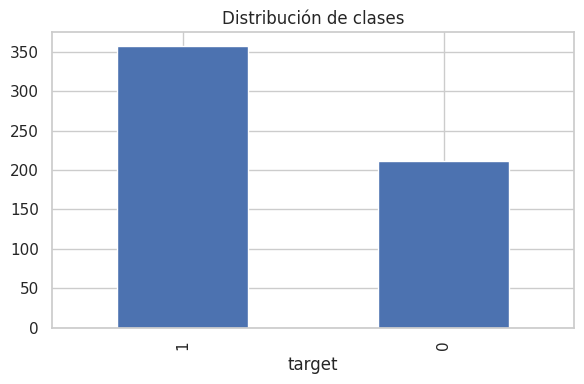

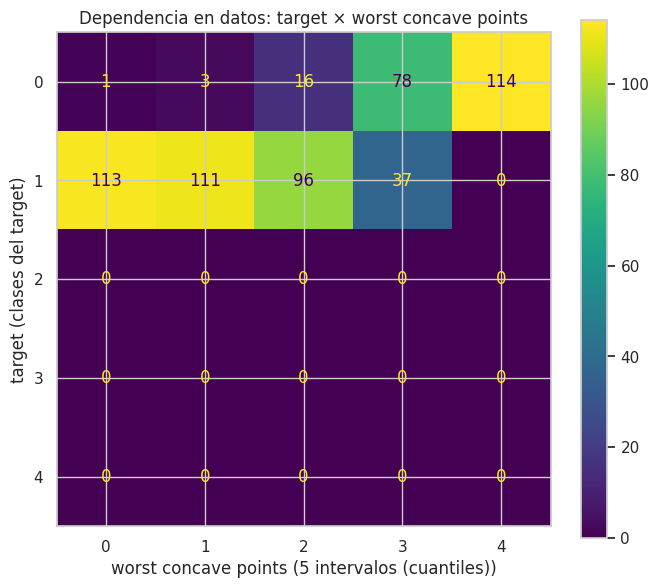

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
df[TARGET_COL].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Distribución de clases")
ax.set_xlabel(TARGET_COL)
plt.tight_layout()
plt.show()

feature_cols_eda = infer_feature_columns(df, TARGET_COL, DROP_COLS, FEATURE_COLS)

# Feature para matriz target×feature (sin heatmap de correlación)
num_cols = [
    c for c in feature_cols_eda
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
]
top_feat = None
if num_cols and pd.api.types.is_numeric_dtype(df[TARGET_COL]):
    s = df[num_cols].corrwith(df[TARGET_COL]).abs().sort_values(ascending=False)
    if len(s.dropna()):
        top_feat = s.idxmax()

if top_feat is None:
    others = [c for c in feature_cols_eda if c in df.columns and c != TARGET_COL]
    top_feat = others[0] if others else None

# --- Matriz de confusión target × feature (dependencias en datos crudos) ---
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

CM_BINS = 5
CM_MAX_CLASSES = 25

if top_feat is None:
    print("No hay features para la matriz target×feature.")
else:
    y = df[TARGET_COL]
    x = df[top_feat]
    mask = y.notna() & x.notna()
    y_clean, x_clean = y[mask], x[mask]

    if pd.api.types.is_numeric_dtype(y_clean) and y_clean.nunique() > CM_MAX_CLASSES:
        y_disc, y_note = discretize_series(y_clean, CM_BINS, CM_MAX_CLASSES)
    else:
        y_disc = pd.Categorical(y_clean).codes
        y_note = "clases del target"

    if pd.api.types.is_numeric_dtype(x_clean) and x_clean.nunique() > CM_MAX_CLASSES:
        x_disc, x_note = discretize_series(x_clean, CM_BINS, CM_MAX_CLASSES)
    else:
        x_disc = pd.Categorical(x_clean).codes
        x_note = "categorías de la feature"

    cm = confusion_matrix(y_disc, x_disc)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=True)
    ax.set_xlabel(f"{top_feat} ({x_note})")
    ax.set_ylabel(f"{TARGET_COL} ({y_note})")
    ax.set_title(f"Dependencia en datos: {TARGET_COL} × {top_feat}")
    plt.tight_layout()
    plt.show()


## 6. X / y y split (estratificado)


In [7]:
feature_cols = infer_feature_columns(df, TARGET_COL, DROP_COLS, FEATURE_COLS)
X = df[feature_cols]
y = df[TARGET_COL]
numeric_cols, categorical_cols = infer_column_types(X, NUMERIC_COLS, CATEGORICAL_COLS)

print("Numéricas:", len(numeric_cols), "| Categóricas:", len(categorical_cols))


X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
    X, y,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=True,
)
print(
    f"Tamaños → train: {len(X_train):,} | val: {len(X_val):,} | test: {len(X_test):,}"
)



Numéricas: 30 | Categóricas: 0
Tamaños → train: 341 | val: 114 | test: 114


## 7. Preprocesado


In [8]:
preprocess = build_preprocess(numeric_cols, categorical_cols)


## 8. Comparar modelos

Métricas en **train** y **val**; la brecha train−val ayuda a detectar **overfitting**.



In [ ]:
# --- Paso 8: métricas y benchmark de modelos ---

OVERFIT_GAP_WARN = 0.15  # brecha train-val en METRIC_PRINCIPAL por encima → posible overfitting

def classification_metrics(y_true, y_pred):
    """Accuracy, precision, recall y F1 de la clase positiva (1)."""
    from sklearn.metrics import (
        accuracy_score,
        f1_score,
        precision_score,
        recall_score,
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


def evaluate_models(models, preprocess, X_train, X_val, y_train, y_val):
    """Entrena en train; métricas en train y val para detectar overfitting."""
    rows = []
    metric = METRIC_PRINCIPAL
    for name, estimator in models.items():
        pipe = Pipeline([("preprocess", preprocess), ("model", estimator)])
        pipe.fit(X_train, y_train)
        m_train = classification_metrics(y_train, pipe.predict(X_train))
        m_val = classification_metrics(y_val, pipe.predict(X_val))
        row = {"modelo": name}
        for k, v in m_train.items():
            row[f"{k}_train"] = v
        for k, v in m_val.items():
            row[f"{k}_val"] = v
        row[f"gap_{metric}"] = m_train[metric] - m_val[metric]
        rows.append(row)
    return pd.DataFrame(rows).sort_values(f"{metric}_val", ascending=False)


results = evaluate_models(MODELS, preprocess, X_train, X_val, y_train, y_val)
display(results.round(4))

gap_col = f"gap_{METRIC_PRINCIPAL}"
sospechosos = results[results[gap_col] > OVERFIT_GAP_WARN]
if len(sospechosos):
    print(
        f"\nPosible overfitting (gap {METRIC_PRINCIPAL} train-val > {OVERFIT_GAP_WARN}):"
    )
    display(
        sospechosos[
            ["modelo", f"{METRIC_PRINCIPAL}_train", f"{METRIC_PRINCIPAL}_val", gap_col]
        ].round(4)
    )
else:
    print(
        f"\nSin gap {METRIC_PRINCIPAL} train-val > {OVERFIT_GAP_WARN} "
        "(no hay señal fuerte de overfitting en el benchmark)."
    )

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = results.set_index("modelo")[
    [f"{METRIC_PRINCIPAL}_train", f"{METRIC_PRINCIPAL}_val"]
]
plot_df.plot(kind="barh", ax=ax)
ax.set_xlabel(METRIC_PRINCIPAL)
ax.set_title("Train vs validación — clasificación binaria")
ax.legend(["train", "val"])
plt.tight_layout()
plt.show()




## 9. Detalle del mejor modelo


Mejor modelo (val): LogisticRegression

Métricas en test (tras reentrenar con train+val):


,accuracy,precision,recall,f1
0,0.9825,0.9861,0.9861,0.9861



              precision    recall  f1-score   support

      benign       0.98      0.98      0.98        42
   malignant       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



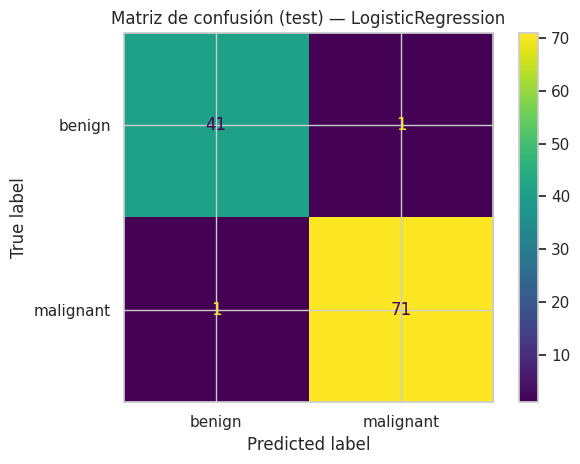

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best_name = results.iloc[0]["modelo"]
print(f"Mejor modelo (val): {best_name}\n")

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

best_pipe = Pipeline([("preprocess", preprocess), ("model", MODELS[best_name])])
best_pipe.fit(X_trainval, y_trainval)
y_pred = best_pipe.predict(X_test)

print("Métricas en test (tras reentrenar con train+val):")
display(pd.DataFrame([classification_metrics(y_test, y_pred)]).round(4))
print()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=CLASS_NAMES
)
plt.title(f"Matriz de confusión (test) — {best_name}")
plt.tight_layout()
plt.show()



## Checklist: nuevo dataset (binaria)

1. CSV en `data/` → explorar (sección 1) → CONFIG (sección 2).
2. Target **0/1** en `TARGET_COL` (`RAW_LABEL_COL` + `LABEL_TO_ID` si el CSV trae texto).
3. `DROP_COLS`: ids, columnas con *leakage* (información del futuro).
4. Comprueba balance de clases antes del split estratificado.
5. Métrica principal habitual: **F1** (especialmente si hay desbalance).
